This script takes as input the spike maps, i.e. there is a file per subject with 256 positive spike channels and 256 negative spike channels. The script generates an array of shape 16x16x2xT, with T 25000 samples, for each and every subject. It also generates another array with 5 finger force and a gain factor applied to each force.

In [ ]:
import numpy as np
from pathlib import Path
import wfdb
from math import gcd
from scipy import signal

# ── CONFIG ────────────────────────────────────────────────────────────────────
data_root  = Path("C:\\Users\\murfe\\Desktop\\PAPER\\hyser_partial")
base_dir   = data_root / "1dof_dataset"
spike_root = data_root / "spike_maps_updated_2"
out_root   = data_root / "preprocessed_mapped"
out_root.mkdir(parents=True, exist_ok=True)

fs          = 1000
FORCE_GAIN  = 100.0

fingers = [f"finger{i}" for i in range(1, 6)]
samples = ["sample1", "sample2", "sample3"]
subjects = sorted([p.name for p in base_dir.iterdir() if p.is_dir()])
print(f"Soggetti trovati: {len(subjects)}")

Soggetti trovati: 40


In [ ]:
# ── HELPERS ───────────────────────────────────────────────────────────────────
def resample_to_target_fs(x, fs_in, fs_target, axis=0):
    fs_in = int(fs_in); fs_target = int(fs_target)
    g = gcd(fs_in, fs_target)
    return signal.resample_poly(x, fs_target // g, fs_in // g, axis=axis)

def lowpass_zero_phase(x, fs_orig, cutoff=10, order=4):
    b, a = signal.butter(order, cutoff / (fs_orig / 2), btype="low")
    return signal.filtfilt(b, a, x, axis=0)

def load_force(subject, finger, sample, fs_target=1000):
    force_rec  = wfdb.rdrecord(str(base_dir / subject / f"1dof_force_{finger}_{sample}"))
    force_raw  = force_rec.p_signal
    fs_force   = float(force_rec.fs)
    force_lp   = lowpass_zero_phase(force_raw, fs_force, cutoff=10)
    return resample_to_target_fs(force_lp, fs_force, fs_target, axis=0)

# The emg signal is recorded through 4 square patches of 8X8 electrodes called B1, B2, B3, and B4.
def spikes_to_2x16x16(pos, neg):
    """
    pos, neg: (T, 256)
    Mappa: (T, 2, 16, 16) con layout fisico [B1|B3 / B2|B4]
    """
    T = pos.shape[0]
    pos4 = pos.reshape(T, 4, 8, 8)
    neg4 = neg.reshape(T, 4, 8, 8)

    out_pos = np.zeros((T, 16, 16), dtype=np.float32)
    out_neg = np.zeros((T, 16, 16), dtype=np.float32)

    # [B1|B3]
    # [B2|B4]
    out_pos[:, 0:8,  0:8]  = pos4[:, 0]   # B1 TL
    out_pos[:, 0:8,  8:16] = pos4[:, 2]   # B3 TR
    out_pos[:, 8:16, 0:8]  = pos4[:, 1]   # B2 BL
    out_pos[:, 8:16, 8:16] = pos4[:, 3]   # B4 BR

    out_neg[:, 0:8,  0:8]  = neg4[:, 0]
    out_neg[:, 0:8,  8:16] = neg4[:, 2]
    out_neg[:, 8:16, 0:8]  = neg4[:, 1]
    out_neg[:, 8:16, 8:16] = neg4[:, 3]

    return np.stack([out_pos, out_neg], axis=1)   # (T, 2, 16, 16)

In [ ]:
# ── MAIN LOOP ─────────────────────────────────────────────────────────────────
for subj in subjects:
    for finger in fingers:
        for samp in samples:
            spike_path = spike_root / f"spikes_{subj}_{finger}_{samp}.npz"
            if not spike_path.exists():
                print(f"Spike file mancante: {spike_path.name}")
                continue

            try:
                # 1. Carica spike maps (T, 256)
                spk = np.load(spike_path)
                pos = spk["pos"].astype(np.float32)   # (T, 256)
                neg = spk["neg"].astype(np.float32)   # (T, 256)

                # 2. Mapping fisico 256 -> (T, 2, 16, 16)
                spikes_2ch = spikes_to_2x16x16(pos, neg)

                # 3. Carica forza e allinea temporalmente
                F_force = load_force(subj, finger, samp, fs_target=fs)
                T = min(spikes_2ch.shape[0], F_force.shape[0])
                spikes_2ch = spikes_2ch[:T]
                F_norm = (F_force[:T]*FORCE_GAIN).astype(np.float32)  # (T, 5)

                # 4. Salva
                out_path = out_root / f"mapped_{subj}_{finger}_{samp}.npz"
                np.savez_compressed(
                    out_path,
                    spikes    = spikes_2ch,             # (T, 2, 16, 16)
                    force     = F_norm,                  # (T, 5)
                    FORCE_GAIN= np.float32(FORCE_GAIN),
                    subject   = subj,
                    finger    = finger,
                    sample    = samp,
                )
                print(f"  {out_path.name}  spikes={spikes_2ch.shape}  force={F_norm.shape}")

            except Exception as e:
                print(f"  ERRORE : {subj} {finger} {samp}: {e}")

print("\nDone!")

  ✅ mapped_subject01_session1_finger1_sample1.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger1_sample2.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger1_sample3.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger2_sample1.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger2_sample2.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger2_sample3.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger3_sample1.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger3_sample2.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger3_sample3.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger4_sample1.npz  spikes=(25000, 2, 16, 16)  force=(25000, 5)
  ✅ mapped_subject01_session1_finger4_sample2.npz 

File: mapped_subject01_session2_finger1_sample1.npz
  spikes shape : (25000, 2, 16, 16)   dtype=float32
  force  shape : (25000, 5)    dtype=float32
  FORCE_GAIN   : 100.0
  Durata       : 25.0 s  (25000 campioni @ 1000 Hz)

── Spike stats ──────────────────────────────────────────
  SR POS  — mean: 0.0407  min: 0.0198  max: 0.1179
  SR NEG  — mean: 0.0439  min: 0.0212  max: 0.1175
  Canali attivi POS: 256/256
  Canali attivi NEG: 256/256
  Canali killed (SR>0.5): POS 0  NEG 0

── Forza stats (valori normalizzati) ────────────────────
  finger1: min=-54.8498  max=28.9526  mean=0.2690  (denorm max=2895.26)
  finger2: min=-3.4276  max=5.9326  mean=0.3297  (denorm max=593.26)
  finger3: min=-2.6908  max=2.6146  mean=-0.2123  (denorm max=261.46)
  finger4: min=-1.7076  max=0.7290  mean=-0.2608  (denorm max=72.90)
  finger5: min=-0.6635  max=4.0858  mean=1.5148  (denorm max=408.58)


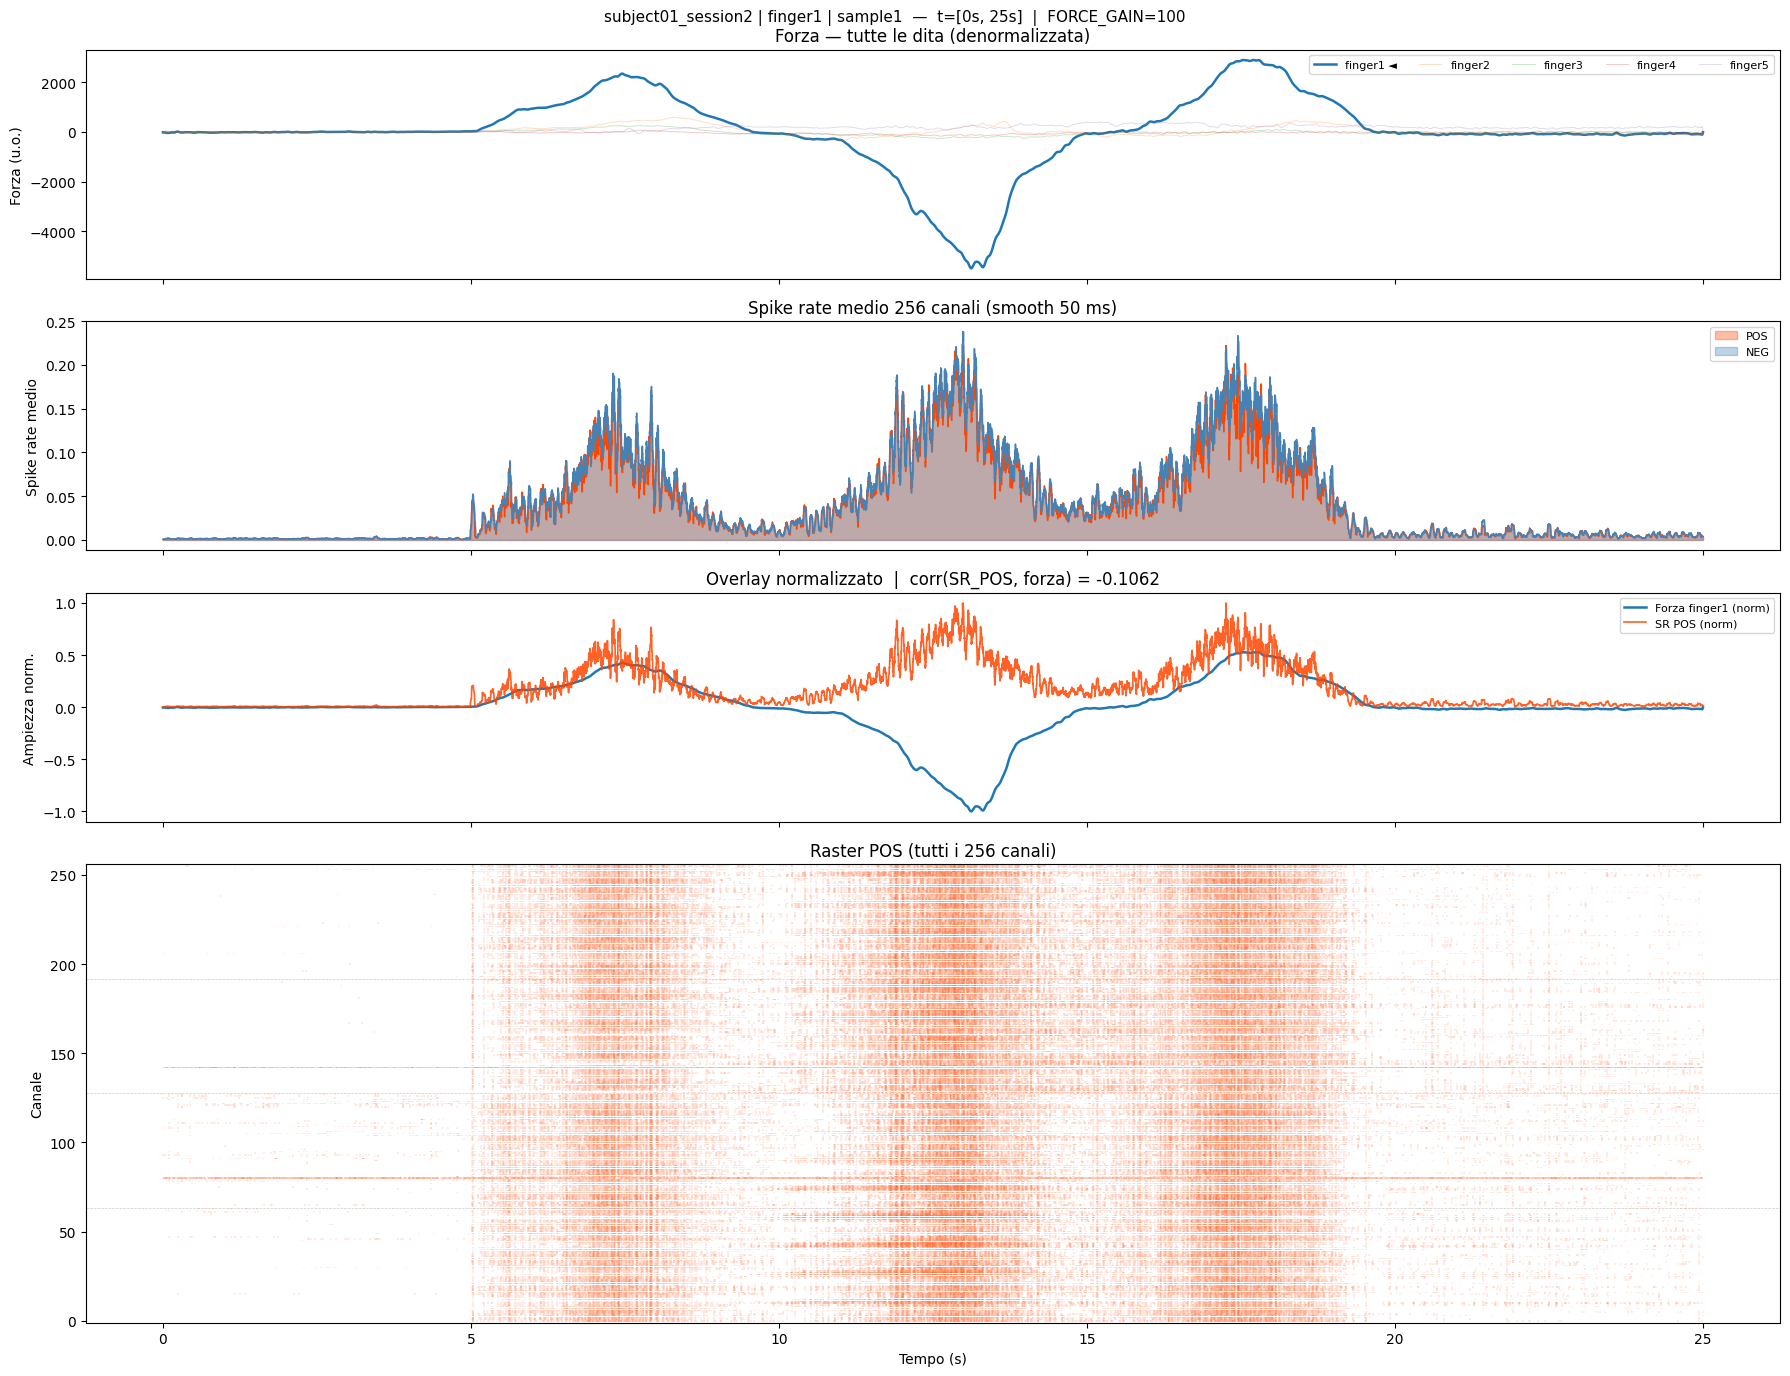

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

subj_check   = "subject01_session2"
finger_check = "finger1"
samp_check   = "sample1"
t_start      = 0
n_sec        = 25
kernel_ms    = 50

npz_path = out_root / f"mapped_{subj_check}_{finger_check}_{samp_check}.npz"
data     = np.load(npz_path)

spikes    = data["spikes"]     # (T, 2, 16, 16)
force     = data["force"]      # (T, 5)  — già divisa per FORCE_GAIN
FG        = float(data["FORCE_GAIN"])
T_full    = spikes.shape[0]
fi_idx    = int(finger_check.replace("finger", "")) - 1

# ── FINESTRA ─────────────────────────────────────────────────────────────────
t_end    = min(t_start + int(n_sec * fs), T_full)
spk_w    = spikes[t_start:t_end]
force_w  = force[t_start:t_end]
T_w      = spk_w.shape[0]
t_axis   = np.arange(T_w) / fs

pos_flat = spk_w[:, 0].reshape(T_w, -1)
neg_flat = spk_w[:, 1].reshape(T_w, -1)

k          = max(1, int(kernel_ms * fs / 1000))
kernel_box = np.ones(k) / k
sr_pos = np.convolve(pos_flat.mean(axis=1), kernel_box, mode="same")
sr_neg = np.convolve(neg_flat.mean(axis=1), kernel_box, mode="same")

# ── PLOT ──────────────────────────────────────────────────────────────────────
colors_f = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 2, 4]})
fig.suptitle(
    f"{subj_check} | {finger_check} | {samp_check}  —  "
    f"t=[{t_start/fs:.0f}s, {t_end/fs:.0f}s]  |  FORCE_GAIN={FG:.0f}",
    fontsize=11
)

# 1 — forza tutte le dita (denormalizzata)
for fi2 in range(5):
    alpha = 1.0 if fi2 == fi_idx else 0.25
    lw    = 1.8 if fi2 == fi_idx else 0.7
    axes[0].plot(t_axis, force_w[:, fi2] * FG,
                 color=colors_f[fi2], alpha=alpha, lw=lw,
                 label=f"finger{fi2+1}" + (" ◄" if fi2 == fi_idx else ""))
axes[0].set_ylabel("Forza (u.o.)")
axes[0].legend(loc="upper right", fontsize=8, ncol=5)
axes[0].set_title("Forza — tutte le dita (denormalizzata)")

# 2 — spike rate POS/NEG smoothed
axes[1].fill_between(t_axis, sr_pos, alpha=0.35, color='orangered', label="POS")
axes[1].fill_between(t_axis, sr_neg, alpha=0.35, color='steelblue', label="NEG")
axes[1].plot(t_axis, sr_pos, color='orangered', lw=1.0)
axes[1].plot(t_axis, sr_neg, color='steelblue', lw=1.0)
axes[1].set_ylabel("Spike rate medio")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title(f"Spike rate medio 256 canali (smooth {kernel_ms} ms)")

# 3 — overlay normalizzato forza target vs SR POS
f_target = force_w[:, fi_idx] * FG
sr_norm  = sr_pos / (sr_pos.max() + 1e-9)
f_norm   = f_target / (np.abs(f_target).max() + 1e-9)
axes[2].plot(t_axis, f_norm,  color=colors_f[fi_idx], lw=1.8, label=f"Forza {finger_check} (norm)")
axes[2].plot(t_axis, sr_norm, color='orangered',       lw=1.2, alpha=0.85, label="SR POS (norm)")
axes[2].set_ylabel("Ampiezza norm.")
axes[2].legend(loc="upper right", fontsize=8)
corr = np.corrcoef(sr_pos, f_target)[0, 1]
axes[2].set_title(f"Overlay normalizzato  |  corr(SR_POS, forza) = {corr:.4f}")

# 4 — raster POS tutti i canali
for ch in range(256):
    t_spk = t_axis[pos_flat[:, ch] > 0]
    if len(t_spk):
        axes[3].vlines(t_spk, ch - 0.4, ch + 0.4,
                       color='orangered', lw=0.3, alpha=0.5)
for b in [64, 128, 192]:
    axes[3].axhline(b - 0.5, color='gray', lw=0.5, ls='--', alpha=0.4)
axes[3].set_ylim(-1, 256)
axes[3].set_ylabel("Canale")
axes[3].set_title("Raster POS (tutti i 256 canali)")
axes[3].set_xlabel("Tempo (s)")

plt.tight_layout()
plt.show()